In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

repo_root = Path().resolve().parents[0]  # notebooks/ -> repo root
sys.path.insert(0, str(repo_root))

In [4]:
import pickle as pkl
from src.dataset.dataset import TracesDataset

In [40]:
dataset_name = "50salads"

In [41]:
with open(f"../data/raw/{dataset_name}_target.pkl", "rb") as f:
    gtea_target = pkl.load(f)
with open(f"../data/raw/{dataset_name}_softmax.pkl", "rb") as f:
    gtea_source = pkl.load(f)
# with open(f"../data/processed/{dataset_name}_unified.pkl", "rb") as f:
#     gtea_unified = pkl.load(f)

In [42]:
tds = TracesDataset(gtea_target, gtea_source)

In [43]:
from src.utils.pm_utils import discover_process

process_model, init_marking, final_marking = discover_process(tds, "inductive")

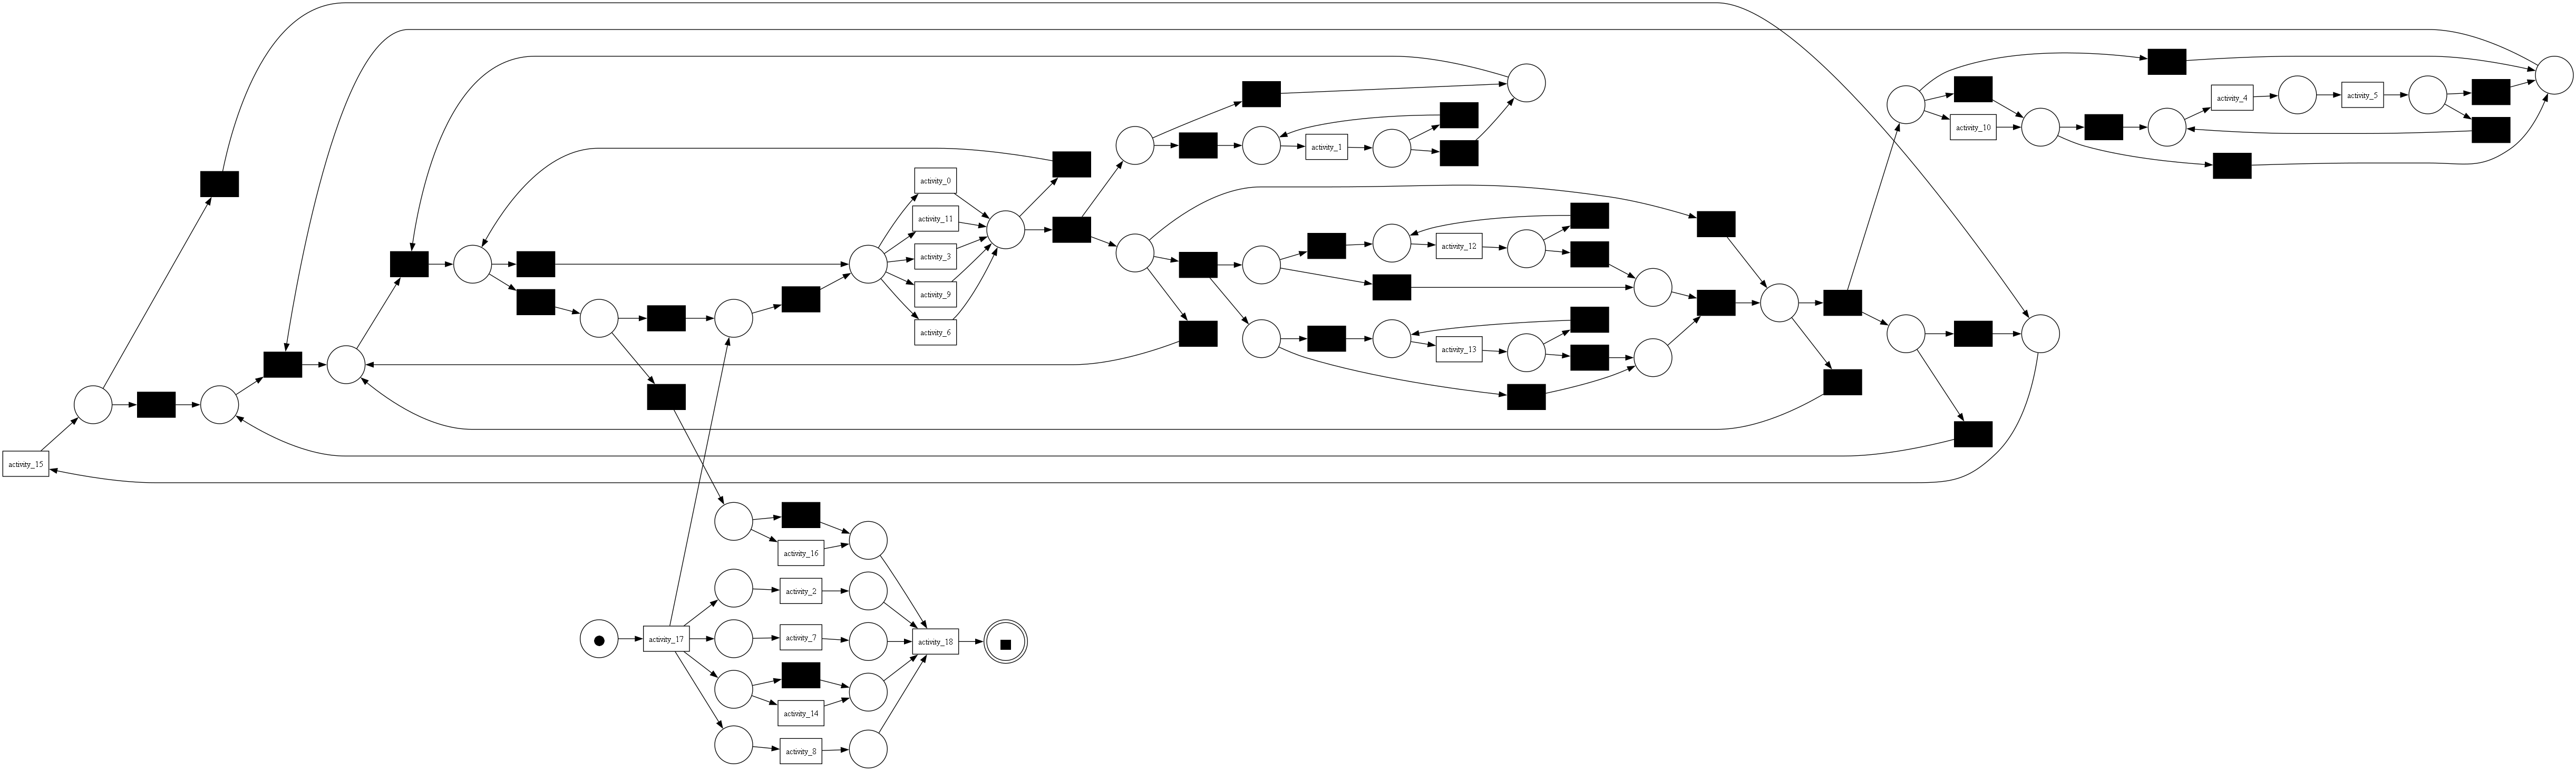

In [44]:
import pm4py

pm4py.view_petri_net(process_model, init_marking, final_marking)

In [45]:
from src.utils.pm_utils import get_petri_net_flow_matrix

flow_matrix = get_petri_net_flow_matrix(process_model, init_marking, final_marking)
flow_matrix.shape

(100, 100)

In [47]:
import numpy as np

np.count_nonzero(flow_matrix) / flow_matrix.size

0.013

In [51]:
from src.utils.graph_utils import prepare_process_model_for_gnn

graph_data = prepare_process_model_for_gnn(process_model, init_marking, final_marking)
graph_data.edge_index.shape

torch.Size([2, 130])